# Pipeline Pengeluaran: docx → master dataset (CSV)

Alur: baca `Raw/Pengeluaran*.docx` → parse bullet → normalisasi item → top 10 & total bulan → frekuensi → terapkan `category_map.json` → simpan ke `dataset/`.

Struktur folder (relatif terhadap lokasi notebook):
```
Raw/         PengeluaranAgustus2025.docx, PengeluaranMei2026.docx, ...
dataset/     (dibuat otomatis)
category_map.json
```
Dependensi: `pip install python-docx pandas matplotlib`

In [125]:
%pip install python-docx pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Konfigurasi

In [126]:
import re
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from docx import Document

from difflib import SequenceMatcher

BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "Raw"
DATASET_DIR = BASE_DIR / "dataset"
CATEGORY_MAP_PATH = BASE_DIR / "category_map.json"
DATASET_DIR.mkdir(exist_ok=True)

MONTHS_ID = {
    "januari": 1, "februari": 2, "maret": 3, "april": 4, "mei": 5, "juni": 6,
    "juli": 7, "agustus": 8, "september": 9, "oktober": 10, "november": 11, "desember": 12,
}

# isi baris yang berarti "tidak ada pengeluaran"
NONE_TOKENS = {"", "none", "nan", "-", "null"}

# kata pengisi yang dibuang dari nama item (contoh: "Member Gym awal" -> "member gym")
FILLER_WORDS = {"awal"}

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

## 2. Fungsi parser

In [127]:
LINE_RE = re.compile(r"^\s*(\d{1,2})\s+[A-Za-z]+\s*[.:]?\s*(.*)$", re.S)
CHUNK_RE = re.compile(r"^(.+?)\s+(\d+(?:[.,]\d+)*)\s*(k|rb|ribu|jt|juta)?$", re.I)


def parse_amount(num, unit):
    """'10' + 'k' -> 10000 | '1.5' + 'k' -> 1500 | '10.000' + None -> 10000"""
    unit = (unit or "").lower()
    if unit in ("k", "rb", "ribu"):
        return int(round(float(num.replace(",", ".")) * 1_000))
    if unit in ("jt", "juta"):
        return int(round(float(num.replace(",", ".")) * 1_000_000))
    return int(num.replace(".", "").replace(",", ""))


def normalize_item(text):
    """lowercase, '&' dan '_' jadi spasi, buang kata pengisi. 'Kopi & susu' -> 'kopi susu'"""
    text = text.lower().replace("&", " ").replace("_", " ")
    words = [w for w in text.split() if w not in FILLER_WORDS]
    return " ".join(words)


def parse_filename(path):
    """PengeluaranAgustus2025.docx -> (2025, 8). Return None kalau nama tidak sesuai."""
    m = re.fullmatch(r"pengeluaran([a-z]+)(\d{4})", path.stem.lower())
    if not m or m.group(1) not in MONTHS_ID:
        return None
    return int(m.group(2)), MONTHS_ID[m.group(1)]


def read_bullets(path):
    """Ambil paragraf bullet dari docx (deteksi lewat numPr atau style 'List ...')."""
    doc = Document(path)
    lines = []
    for p in doc.paragraphs:
        text = p.text.strip()
        if not text:
            continue
        pPr = p._p.pPr
        has_numbering = pPr is not None and pPr.numPr is not None
        style_is_list = "list" in (p.style.name or "").lower()
        if has_numbering or style_is_list:
            lines.append(text)
    return lines


def parse_line(line):
    """
    '1 Agustus. Kopi & susu 10k, mie ayam 10k = 59k.'
      -> (1, [('kopi susu', 10000), ('mie ayam', 10000)])
    Bulan di isi baris diabaikan (bulan diambil dari nama file).
    Total harian setelah '=' dibuang. Hari kosong -> (hari, []).
    """
    m = LINE_RE.match(line)
    if not m:
        raise ValueError("format baris tidak dikenali")
    day = int(m.group(1))
    body = m.group(2).partition("=")[0].strip(" .,;")

    if body.lower() in NONE_TOKENS:
        return day, []

    items = []
    for chunk in body.split(","):
        chunk = chunk.strip(" .;")
        if not chunk:
            continue
        cm = CHUNK_RE.match(chunk)
        if not cm:
            raise ValueError(f"item tidak terbaca: '{chunk}'")
        items.append((normalize_item(cm.group(1)), parse_amount(cm.group(2), cm.group(3))))
    return day, items

## 3. Baca seluruh docx di `Raw/` → data master (mentah)

In [128]:
def build_raw_dataset():
    rows, warnings = [], []
    files = sorted(f for f in RAW_DIR.glob("Pengeluaran*.docx") if not f.name.startswith("~$"))
    if not files:
        raise FileNotFoundError(f"Tidak ada file Pengeluaran*.docx di {RAW_DIR}")

    for f in files:
        ym = parse_filename(f)
        if ym is None:
            warnings.append(f"{f.name} | nama file tidak sesuai pola PengeluaranBulanTahun.docx, dilewati")
            continue
        year, month = ym

        for line in read_bullets(f):
            try:
                day, items = parse_line(line)
                date = pd.Timestamp(year=year, month=month, day=day)
            except Exception as e:
                warnings.append(f"{f.name} | {e} | {line}")
                continue

            if not items:                       # hari tanpa pengeluaran -> 1 baris None
                items = [(None, None)]
            for item, amount in items:
                rows.append({
                    "date": date, "year": year, "month": month, "day": day,
                    "item": item, "amount": amount,
                    "source_file": f.name, "raw_line": line,
                })

    df = pd.DataFrame(rows)
    df = df.sort_values("date", kind="stable").reset_index(drop=True)   # stabil: urutan dalam satu hari terjaga
    df.insert(0, "id", range(1, len(df) + 1))
    df["amount"] = df["amount"].astype("Int64")
    return df, warnings


df, warnings = build_raw_dataset()

ALIAS_PATH = BASE_DIR / "item_alias.json"
item_alias = json.load(open(ALIAS_PATH, encoding="utf-8")) if ALIAS_PATH.exists() else {}

df["item"] = df["item"].map(lambda x: item_alias.get(x, x) if isinstance(x, str) else x)

print(f"{len(df)} baris dari {df['source_file'].nunique()} file")

if warnings:
    print(f"\n{len(warnings)} peringatan:")
    for w in warnings:
        print("  -", w)

# nominal < 1000 kemungkinan lupa menulis 'k' (contoh: 'sarapan 21' seharusnya '21k')
suspicious = df[df["amount"].notna() & (df["amount"] < 1000)]
if len(suspicious):
    print("\nNominal mencurigakan (< Rp1.000), cek apakah lupa tulis 'k':")
    display(suspicious[["id", "date", "item", "amount", "source_file"]])

1297 baris dari 15 file


## 4. Top 10 data & total per bulan

In [129]:
display(df.drop(columns=["raw_line"]).head(10))

monthly = (
    df.groupby(["year", "month"])
      .agg(total=("amount", "sum"),
           transaksi=("item", "count"),          # count() mengabaikan None
           hari_tercatat=("date", "nunique"))
      .reset_index()
)
monthly["rata_rata_per_hari"] = (monthly["total"] / monthly["hari_tercatat"]).round(0)
display(monthly)

,id,date,year,month,day,item,amount,source_file
0,1,2025-07-01,2025,7,1,bensin,25000,PengeluaranJuli2025.docx
1,2,2025-07-01,2025,7,1,air,12000,PengeluaranJuli2025.docx
2,3,2025-07-01,2025,7,1,parkir,10000,PengeluaranJuli2025.docx
3,4,2025-07-01,2025,7,1,makan,20000,PengeluaranJuli2025.docx
4,5,2025-07-02,2025,7,2,bensin,30000,PengeluaranJuli2025.docx
5,6,2025-07-02,2025,7,2,jajan,16000,PengeluaranJuli2025.docx
6,7,2025-07-02,2025,7,2,makan siang,15000,PengeluaranJuli2025.docx
7,8,2025-07-02,2025,7,2,masuk pantai,16000,PengeluaranJuli2025.docx
8,9,2025-07-02,2025,7,2,sabun,3000,PengeluaranJuli2025.docx
9,10,2025-07-02,2025,7,2,makan,13000,PengeluaranJuli2025.docx


,year,month,total,transaksi,hari_tercatat,rata_rata_per_hari
0,2025,7,2149500,118,31,69339.0
1,2025,8,1534000,72,31,49484.0
2,2025,9,1668500,102,30,55617.0
3,2025,10,1927000,118,31,62161.0
4,2025,11,1484000,81,30,49467.0
5,2025,12,1988000,99,31,64129.0
6,2026,1,2004000,105,31,64645.0
7,2026,2,1116000,66,28,39857.0
8,2026,3,1907000,41,31,61516.0
9,2026,4,1574500,84,30,52483.0


## 5. Jenis pengeluaran terbanyak (frekuensi item)

In [130]:
expense = df.dropna(subset=["item"])
print("Item paling sering muncul:")
display(expense["item"].value_counts().head(10).rename("frekuensi").to_frame())

Item paling sering muncul:


,frekuensi
item,
lauk,117
bensin,86
susu,71
ayam,53
soto,52
minum,42
makan,39
jajan,33
kopi,33


## 6. Terapkan `category_map.json`

In [131]:
def load_category_map(path):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return {cat: [kw.lower() for kw in kws] for cat, kws in raw.items()}


def categorize(item, cmap):
    """Keyword terpanjang yang cocok menang. Tidak ada yang cocok -> 'Uncategorized'. Item None -> None."""
    if item is None or pd.isna(item):
        return None
    best_cat, best_len = "Uncategorized", 0
    for cat, keywords in cmap.items():
        for kw in keywords:
            if len(kw) > best_len and re.search(rf"\b{re.escape(kw)}\b", item):
                best_cat, best_len = cat, len(kw)
    return best_cat


category_map = load_category_map(CATEGORY_MAP_PATH)
df_master = df.copy()
df_master["category"] = df_master["item"].apply(lambda x: categorize(x, category_map))

unmapped = df_master.loc[df_master["category"] == "Uncategorized", "item"].value_counts()
if len(unmapped):
    print("Item belum terpetakan (tambahkan ke category_map.json):")
    display(unmapped.rename("frekuensi").to_frame())
else:
    print("Semua item sudah terpetakan.")

print("\nKategori paling sering (frekuensi):")
display(df_master["category"].value_counts().rename("frekuensi").to_frame())

Item belum terpetakan (tambahkan ke category_map.json):


,frekuensi
item,
tas,2
minun,2
materai,2
masuk pantai,1
km mandi,1
...,...
fc,1
cap jay,1
surat kesehatan,1



Kategori paling sering (frekuensi):


,frekuensi
category,
Makanan & Minuman,698
Uncategorized,145
Transportasi,128
Jajan,98
Kebutuhan Rumah,77
Olahraga,30
Kebutuhan Diri,20
Elektronik & Hobi,14
Lain-lain,10


In [132]:
# from difflib import SequenceMatcher

TOP_N = 10          # naikkan kalau cakupan masih rendah
SIM_CUTOFF = 0.85   # semakin tinggi semakin ketat
MIN_LEN = 4         # kata lebih pendek dari ini tidak dicek kemiripannya

unm = df_master.loc[df_master["category"] == "Uncategorized", "item"].value_counts()

# 1) top N + cakupan kumulatif
top = unm.head(TOP_N)
display(pd.DataFrame({
    "frekuensi": top,
    "kumulatif_%": (top.cumsum() / unm.sum() * 100).round(1),
}))
print(f"{len(unm)} item unik belum terpetakan | top {TOP_N} mencakup {top.sum()} dari {unm.sum()} baris")

# 2) grup item yang mirip (untuk kandidat typo)
def similar_groups(items, cutoff=SIM_CUTOFF, min_len=MIN_LEN):
    items, used, groups = list(items), set(), []
    for i, a in enumerate(items):          # items sudah urut frekuensi
        if a in used:
            continue
        grp = [a]
        for b in items[i + 1:]:
            if b in used or len(a) < min_len or len(b) < min_len:
                continue
            if SequenceMatcher(None, a, b).ratio() >= cutoff:
                grp.append(b)
                used.add(b)
        used.add(a)
        if len(grp) > 1:
            groups.append(grp)
    return groups

for g in similar_groups(unm.index):
    print(" | ".join(f"{x} ({unm[x]})" for x in g))

,frekuensi,kumulatif_%
item,,
tas,2,1.4
minun,2,2.8
materai,2,4.1
masuk pantai,1,4.8
km mandi,1,5.5
kamar mandi,1,6.2
iuran gas,1,6.9
parking,1,7.6
eating,1,8.3


142 item unik belum terpetakan | top 10 mencakup 13 dari 145 baris


## 7. Simpan ke `dataset/`

In [133]:
cols = ["id", "date", "year", "month", "day", "item", "amount", "category", "source_file", "raw_line"]

# lapis 1: hasil parsing tanpa kategori (jadi kalau category_map berubah, tidak perlu parse ulang docx)
df.to_csv(DATASET_DIR / "master_raw.csv", index=False, encoding="utf-8", date_format="%Y-%m-%d")

# lapis 2: master lengkap dengan kategori
df_master[cols].to_csv(DATASET_DIR / "master.csv", index=False, encoding="utf-8", date_format="%Y-%m-%d")

print("Tersimpan:", DATASET_DIR / "master.csv")

Tersimpan: d:\9-Project\MoneyManagement\dataset\master.csv


## 8. Visualisasi cepat

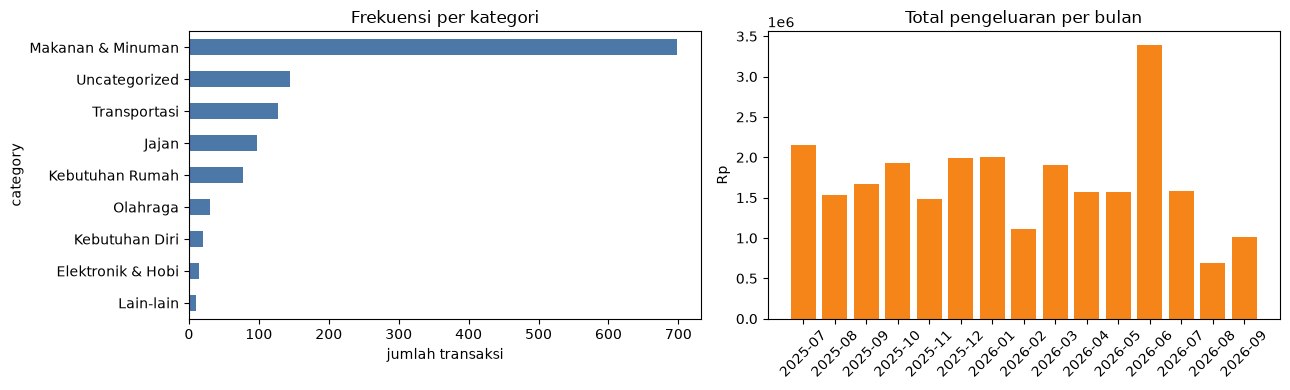

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_master["category"].value_counts().sort_values().plot.barh(ax=axes[0], color="#4C78A8")
axes[0].set_title("Frekuensi per kategori")
axes[0].set_xlabel("jumlah transaksi")

labels = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
axes[1].bar(labels, monthly["total"].astype(float), color="#F58518")
axes[1].set_title("Total pengeluaran per bulan")
axes[1].set_ylabel("Rp")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()